In [1]:

import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS, HMC
from IPython.core.pylabtools import figsize
import numpy as np
import pandas as pd

from pathlib import Path
import glob
from matplotlib import pyplot as plt
from scipy.stats.mstats import mquantiles
from sklearn.preprocessing import MinMaxScaler
from pyro.infer.autoguide import init_to_value


# Parameter determination for function
We specify a bi-Lorentzian model for the ODMR spectra where the mean values change is driven by a learned linear function that depends on temperature. In the first part, we learn the parameters of the linear "calibration" function that maps the peak center positions on to temperature. This learned model- referred to as the calibrated_model-  is then subsequently used to predict temperatures given spectra and associated uncertainty in the predicted value.

## Set up function
Here we import the data, define a bi-Lorentzian function and demonstrate the impact of different values of center 1 and center 2 (A and B, respectively) on the simulated spectra.

In [2]:
temps_ = ['-30', '-20', '-10', '0',
       '10', '20', '30', '40', '50', '40', '30', '20',
       '10', '0', '-10', '-20', '-30']

temps = np.array(temps_, dtype=float)

temps = temps + 273.15  # Convert to Kelvin

temps = torch.tensor(temps).double()

temps = temps[:9]

temp_test_array = np.array(temps_, dtype=float) + 273.15  # Convert to Kelvin
temp_test = torch.tensor(temp_test_array).double()

In [3]:
len(temps)


9

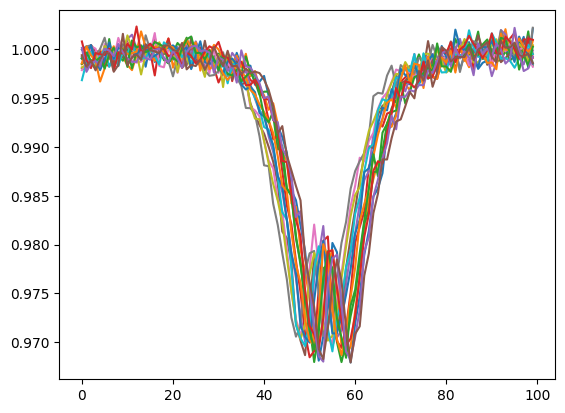

In [4]:
## import data file
fpath = '../saved_data/cycle2'

df_= pd.read_csv(fpath, sep=',', header = 0); 
df= df_.iloc[0:, 1:]
#df.drop(columns= ['25 C-lower power', '15', '10', '10.1', '-30', '-20'], inplace= True)
df.iloc[:, 2:].plot(legend= False)

# define and scale the frequency axis 
x_esr = df.frequency.values
y_esr = df.iloc[:, 1:10]

#scale x axis to 0-100
sc = MinMaxScaler(feature_range=(0, 100))
x_scale = sc.fit_transform(x_esr.reshape(-1, 1)).flatten()

torch.set_default_dtype(torch.float64)


y_esr_ = df.iloc[:, 1:]



In [5]:
df.shape
print(y_esr.columns)
print(temps)

Index(['-30 C', '-20 C up', '-10 C up', '0C up', '10 C up', '20 C up',
       '30 C up', '40 C up', '50'],
      dtype='object')
tensor([243.1500, 253.1500, 263.1500, 273.1500, 283.1500, 293.1500, 303.1500,
        313.1500, 323.1500])


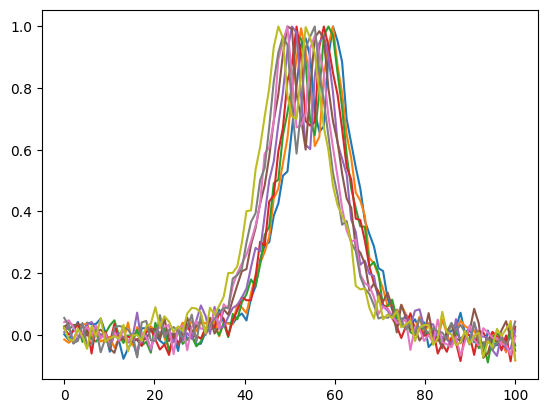

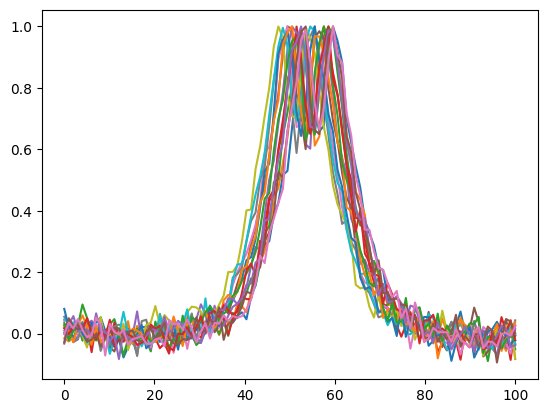

In [6]:
# plot baseline subtracted  y data
y_esr = y_esr.apply(lambda x: x - x[:20].mean())#+0.01
y_esr = -1*y_esr
y_esr = y_esr.apply(lambda x: x/x.max())
plt.plot(x_scale, y_esr); plt.show()
#plt.xlim(40, 80)

y_esr_ = y_esr_.apply(lambda x: x - x[:20].mean())#+0.01
y_esr_ = -1*y_esr_
y_esr_ = y_esr_.apply(lambda x: x/x.max())
plt.plot(x_scale, y_esr_);

In [7]:
#numpy version of function
def F_np(x_in, Amp, alpha, beta, T):
    # Reshape A, B, Amp, G1, G2 for broadcasting with x_in
    alpha = alpha[None, :]
    Amp_reshaped = Amp[None, :]
    T_reshaped = T[None, :]
    beta = beta[None, :]
    A_reshaped = (T_reshaped*alpha) + beta # Shape (1, num_samples)
    X_reshaped = 8.420054307219287
    B_reshaped = A_reshaped + X_reshaped
     # Shape (1, num_samples)
    G1_reshaped = 8.020510711744828 # New: Reshape gamma1
    G2_reshaped = 8.020510711744828 # New: Reshape gamma2
    
    x_in_reshaped = x_in[:, None] # Shape (num_x_points, 1)

    F = (Amp_reshaped) * (0.5 * G1_reshaped) / ((x_in_reshaped - A_reshaped)**2 + (0.5 * G1_reshaped)**2) \
        + (Amp_reshaped) * (0.5 * G2_reshaped) / ((x_in_reshaped - B_reshaped)**2 + (0.5 * G2_reshaped)**2)
    return F


# A function to sample values of A and B and plot resulting function.
def F_samples():
    amp = pyro.sample("Amp", dist.Normal(0.95, 0.25))
    alpha = pyro.sample("alpha", dist.Normal(-71, 7.0)).double() /1000
    beta = pyro.sample("beta", dist.Normal(42., 10.0)) # Sample gamma1
    T_ = torch.tensor(273.15).double()
    T = T_ * np.ones_like(alpha) 
    A =  T*alpha + beta
    B =  A + 8.420054307219287
    gamma1 =  pyro.sample("gamma1", dist.Normal(8.02, 1.0)).double()
    gamma2 = gamma1
    # Use the sampled gamma values in the function
    f_sim = lambda xi: (amp) *(0.5*gamma1)/((xi-A)**2 + (0.5*gamma1)**2) + (amp) *(0.5*gamma2)/((xi-B)**2 + (0.5*gamma2)**2)
    plt.plot(x_scale, f_sim(x_scale))
    # Update title to show sampled gamma values
    plt.title('A:' + str(A.numpy()) + ' B:' + str(B.numpy()) + ' G1:' + str(gamma1.numpy()) + ' G2:' + str(gamma2.numpy()))



## Define data we will start with and plot.

In [8]:

# this will be the data we'll start with, shown as red circles
def dataslicer(x, y, col1 =0 ,col2=1):
    x_scale_tensor = torch.tensor(x).double()
    # squeeze the selected column to produce a 1-D tensor (N,) instead of (N,1)
    y_vals = y.iloc[:, col1:col2].values.squeeze()
    y_scale_tensor = torch.tensor(y_vals).double()
    return x_scale_tensor, y_scale_tensor



(40.0, 70.0)

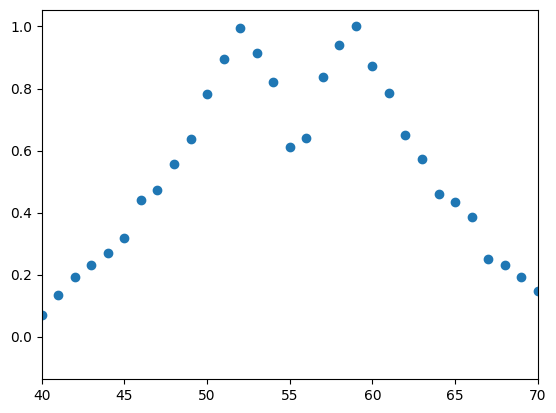

In [9]:
plt.plot(y_esr.iloc[:, 1].values, 'o')
plt.xlim(40,70)

## Set up and run Bayesian inference

In [10]:
# define the model
# Here we assume that we know the noise variance in the data = 0.1,
# though this can be set to another parameter to learn.

x_obs, y_obs = dataslicer(x_scale, y_esr, col1=0, col2=1)
T_ = 273.15 + 25.0  # Example temperature in Kelvin

data_ = (T_, (x_obs.clone().detach().double(), y_obs.clone().detach().double()))

def model(data_):
    T, data, = data_[0], data_[1]
    alpha = pyro.sample("alpha", dist.Normal(-0.077, 0.01)).double() 
    beta = pyro.sample("beta", dist.Normal(70., 10.0)) # Sample gamma1
    var = pyro.sample("var", dist.HalfNormal(scale=0.1)).double()
    gamma1 =  pyro.sample("gamma1", dist.Normal(8.02, 1.0)).double()
    A =  T*alpha + beta
    B =  A + 8.420054307219287
    #gamma1 =  8.020510711744828 
    gamma2 = gamma1#pyro.sample("gamma2", dist.Normal(8.02, 1.0)).double()
    amp =  pyro.sample("amp", dist.Normal(3., 0.25 )).double()
    F =  (amp) * (0.5 * gamma1) / ((data[0] - A)**2 + (0.5 * gamma1)**2) \
        + (amp) * (0.5 * gamma2) / ((data[0] - B)**2 + (0.5 * gamma2)**2)
    
    # ensure F is a 1-D mean vector matching y_obs
    F = F.squeeze()

    #with pyro.plate("data", data[0].size(0)):
    pyro.sample("obs", dist.MultivariateNormal(F, var * torch.eye(data[1].shape[0]).double()), obs=data[1])

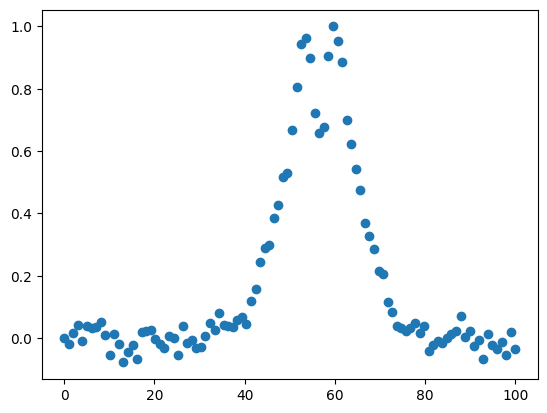

In [11]:
plt.plot(x_obs, y_obs, 'o')
#plt.xlim(40, 70)

In [12]:
temps = torch.tensor(temps).double()

C:\Users\zahmed\AppData\Local\Temp\1\ipykernel_18776\2747252934.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  temps = torch.tensor(temps).double()


In [13]:
# solve for the posterior using MCMC
# Use the observed x positions and y values as the data passed to the model


init_vals = {
    "alpha": torch.tensor(-0.077),
    "beta": torch.tensor(71.0),
    "gamma1": torch.tensor(7.8),
    "amp": torch.tensor(3.0),
    "var": torch.tensor(0.05),}


kernel = NUTS(model, jit_compile=True, init_strategy=init_to_value(values=init_vals), max_tree_depth=6, ignore_jit_warnings=True)
posterior = MCMC(kernel, num_samples=500, warmup_steps=200, num_chains=1)
posterior.run((data_))



Sample: 100%|██████████| 700/700 [02:01,  5.78it/s, step size=3.75e-02, acc. prob=0.950]


#################


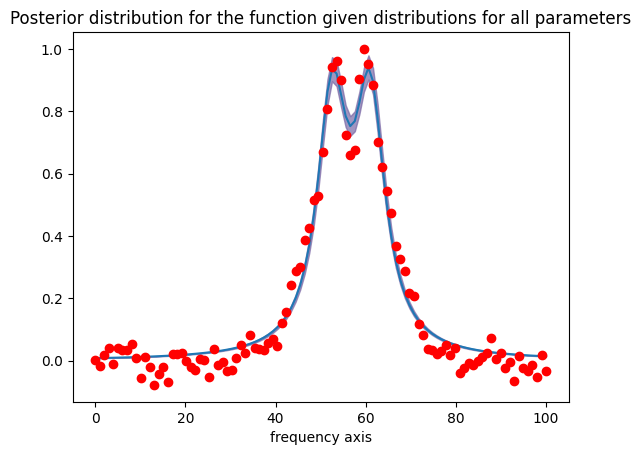

#################


In [14]:


hmc_samples = {k: v.detach().cpu().numpy() for k, v in posterior.get_samples().items()}
alpha = hmc_samples['alpha']
beta = hmc_samples['beta']
Amp = hmc_samples['amp'] # Get posterior samples for amp
var = hmc_samples['var'] # Get posterior samples for var
T = T_ * np.ones_like(alpha)  # Create T array matching alpha shape
F = F_np(x_scale, Amp, alpha, beta, T)
qs = mquantiles(F.T, [0.025, 0.975], axis=0)
F_mean = F.mean(axis = 1)

print('#################')
plt.fill_between(x_scale.flatten(), qs[0], qs[1], alpha=0.7, color="#7A68A6");
plt.plot(x_scale, F_mean)
plt.plot(x_obs, y_obs, 'ro'); # plotting the data for this slice
plt.xlabel('frequency axis')
plt.title('Posterior distribution for the function given distributions for all parameters');plt.show()
pyro.clear_param_store()
print('#################')


In [15]:
print(f'alpha = {np.array(alpha).mean():.4f}')
print(f'alpha error = {np.array(alpha).var():.6f}')
print(f'beta = {np.array(beta).mean():.4f}')
print(f'beta error = {np.array(beta).var():.6f}')
print(f'gamma1 = {np.array(hmc_samples["gamma1"]).mean():.4f}')
print(f'gamma1 error = {np.array(hmc_samples["gamma1"]).var():.6f}')
print(f'amp = {np.array(hmc_samples["amp"]).mean():.4f}')
print(f'amp error = {np.array(hmc_samples["amp"]).var():.6f}')

alpha = -0.0634
alpha error = 0.000006
beta = 71.4449
beta error = 0.540645
gamma1 = 8.0720
gamma1 error = 0.121939
amp = 3.1666
amp error = 0.004481


## Get results and plot

In [16]:
[i for i in range(y_esr_.shape[1])]

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

0
{'alpha': tensor(-0.0760), 'beta': tensor(71.), 'gamma1': tensor(7.8000), 'amp': tensor(3.), 'var': tensor(0.0500)}


Sample: 100%|██████████| 1200/1200 [08:40,  2.30it/s, step size=3.25e-02, acc. prob=0.959]

#################


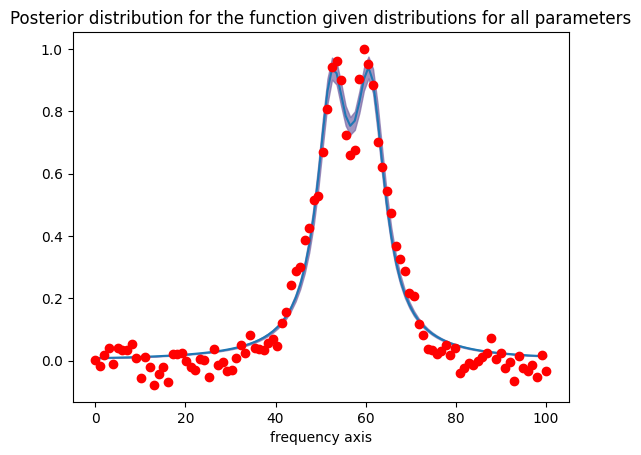

#################
1
{'alpha': tensor(-0.0767), 'beta': tensor(71.1624), 'gamma1': tensor(8.1081), 'amp': tensor(3.1708), 'var': tensor(0.0025)}


Sample: 100%|██████████| 1200/1200 [10:04,  1.99it/s, step size=3.24e-02, acc. prob=0.949]


#################


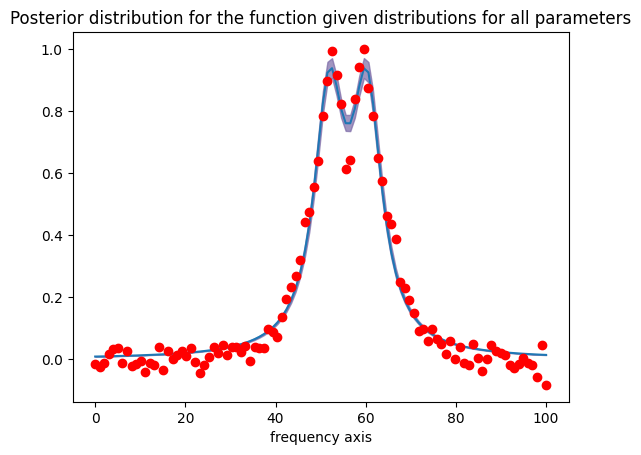

#################
2
{'alpha': tensor(-0.0762), 'beta': tensor(71.1535), 'gamma1': tensor(8.1093), 'amp': tensor(3.1778), 'var': tensor(0.0019)}


Sample: 100%|██████████| 1200/1200 [09:41,  2.06it/s, step size=3.06e-02, acc. prob=0.948]

#################


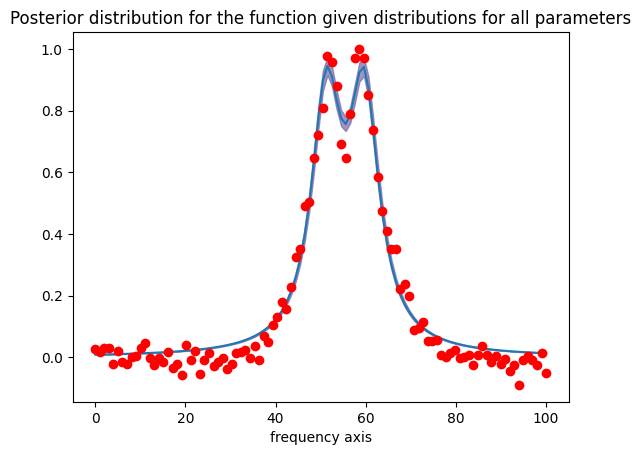

#################
3
{'alpha': tensor(-0.0771), 'beta': tensor(71.5070), 'gamma1': tensor(7.8970), 'amp': tensor(3.1853), 'var': tensor(0.0022)}


Sample: 100%|██████████| 1200/1200 [09:27,  2.11it/s, step size=3.12e-02, acc. prob=0.941]


#################


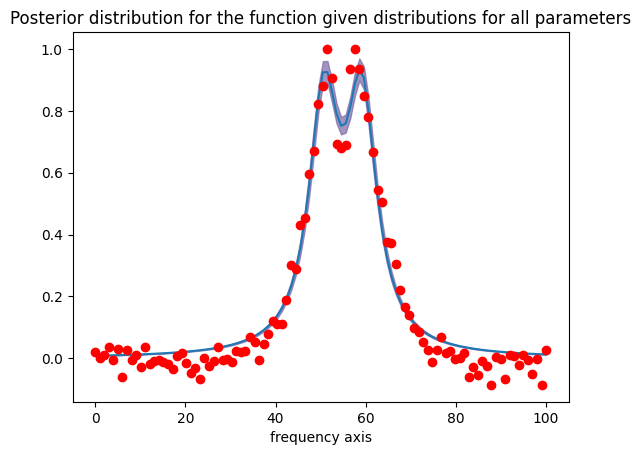

#################
4
{'alpha': tensor(-0.0761), 'beta': tensor(71.4753), 'gamma1': tensor(7.9306), 'amp': tensor(3.1534), 'var': tensor(0.0026)}


Sample: 100%|██████████| 1200/1200 [11:02,  1.81it/s, step size=2.63e-02, acc. prob=0.945]

#################


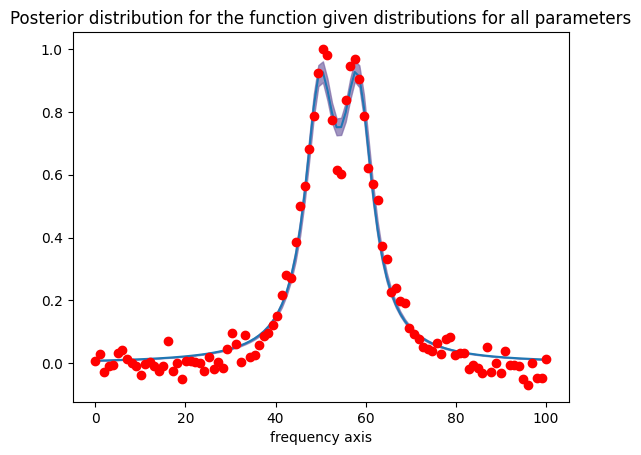

#################
5
{'alpha': tensor(-0.0771), 'beta': tensor(71.6554), 'gamma1': tensor(7.8002), 'amp': tensor(3.1392), 'var': tensor(0.0020)}


Sample: 100%|██████████| 1200/1200 [10:13,  1.96it/s, step size=3.52e-02, acc. prob=0.937]

#################


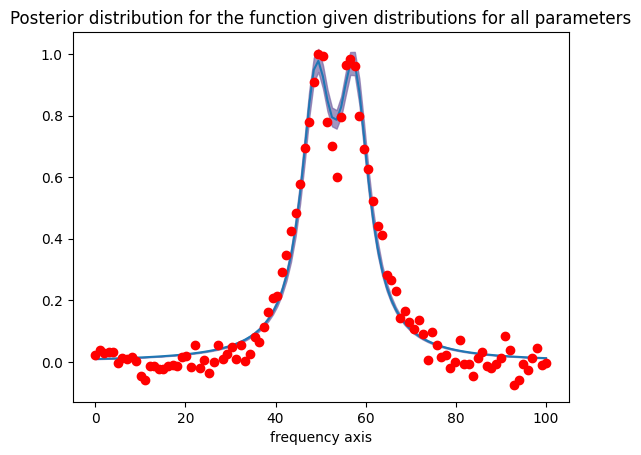

#################
6
{'alpha': tensor(-0.0772), 'beta': tensor(71.6071), 'gamma1': tensor(8.3318), 'amp': tensor(3.3003), 'var': tensor(0.0024)}


Sample: 100%|██████████| 1200/1200 [12:37,  1.58it/s, step size=3.50e-02, acc. prob=0.937]

#################


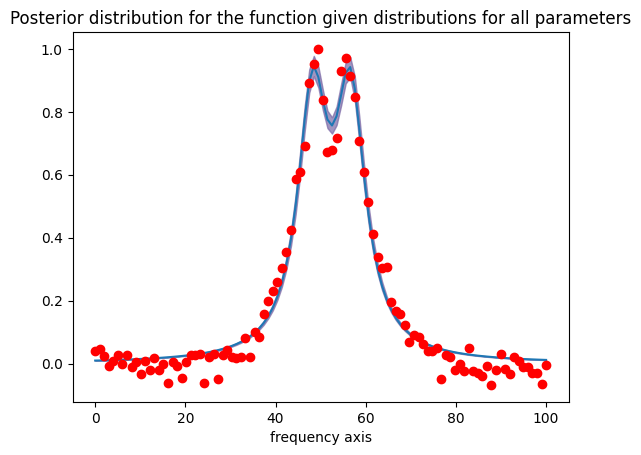

#################
7
{'alpha': tensor(-0.0771), 'beta': tensor(71.5642), 'gamma1': tensor(8.1035), 'amp': tensor(3.1864), 'var': tensor(0.0021)}


Sample: 100%|██████████| 1200/1200 [11:30,  1.74it/s, step size=2.79e-02, acc. prob=0.946]

#################


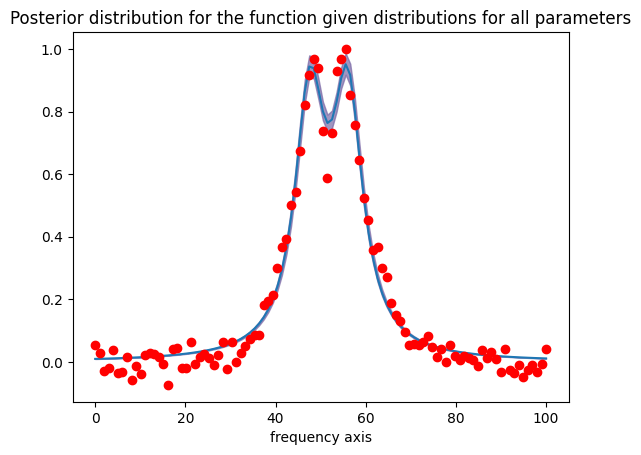

#################
8
{'alpha': tensor(-0.0763), 'beta': tensor(71.4666), 'gamma1': tensor(8.1725), 'amp': tensor(3.2081), 'var': tensor(0.0021)}


Sample: 100%|██████████| 1200/1200 [12:55,  1.55it/s, step size=3.25e-02, acc. prob=0.941]

#################


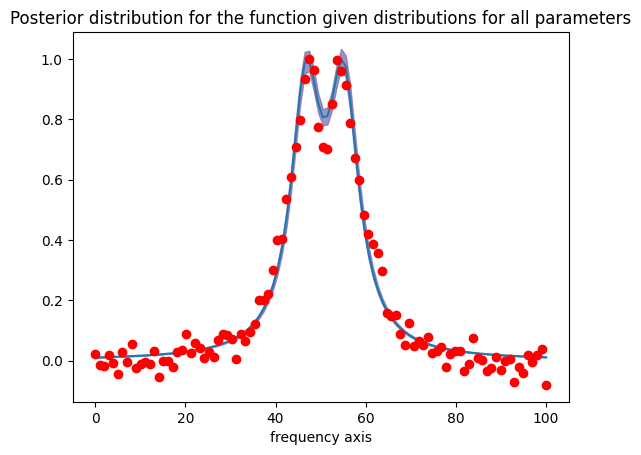

#################


In [17]:
idx = []
error_alpha = []
error_beta = []
alpha_, beta_, amp_ = [], [], []
gamma1_vals = []
beta_var, alpha_var, gamma1_var, amp_var = [], [], [], []

# init vals for MCMC

init_vals = {
    "alpha": torch.tensor(-0.076),
    "beta": torch.tensor(71.0),
    "gamma1": torch.tensor(7.8),
    "amp": torch.tensor(3.0),
    "var": torch.tensor(0.05),}


for j in range(0, y_esr.shape[1]):
  print(j)
  print(init_vals)
  x_obs_j, y_obs_j = dataslicer(x_scale, y_esr, col1=j, col2=j+1)
  temps_j = temps[j]
  data_j_ = (temps_j, (x_obs_j[:].clone().detach().double(), y_obs_j[:].clone().detach().double()))
  kernel = NUTS(model, jit_compile=True, init_strategy=init_to_value(values=init_vals), ignore_jit_warnings=True, max_tree_depth=9)
  posterior = MCMC(kernel, num_samples=1000, warmup_steps=200, num_chains=1)
  posterior.run(data_j_)
  hmc_samples = {k: v.detach().cpu().numpy() for k, v in posterior.get_samples().items()}
  alpha = hmc_samples['alpha']
  beta = hmc_samples['beta']
  Amp = hmc_samples['amp'] # Get posterior samples for amp
  var = hmc_samples['var'] # Get posterior samples for var
  T = temps_j.item() * np.ones_like(alpha)  # Create T array matching alpha shape
  gamma1_ = hmc_samples['gamma1'] # Get posterior samples for gamma1
  gamma2_ = hmc_samples['gamma1'] # Get posterior samples for gamma2 (since gamma2 = gamma1 in the model)
  var = hmc_samples['var'] # Get posterior samples for var
  F = F_np(x_scale, Amp, alpha, beta, T)
  qs = mquantiles(F.T, [0.025, 0.975], axis=0)
  F_mean = F.mean(axis = 1)
  idx.append(j)
  amp_.append(Amp.mean())  
  alpha_.append(alpha.mean())
  beta_.append(beta.mean())
  gamma1_vals.append(gamma1_.mean())
  alpha_var.append(alpha.var())
  beta_var.append(beta.var())
  gamma1_var.append(gamma1_.var())
  amp_var.append(Amp.var())
  print('#################')
  plt.fill_between(x_scale.flatten(), qs[0], qs[1], alpha=0.7, color="#7A68A6")
  plt.plot(x_scale, F_mean)
  plt.plot(x_obs_j, y_obs_j, 'ro'); # plotting the data for this slice
  plt.xlabel('frequency axis')
  plt.title('Posterior distribution for the function given distributions for all parameters');plt.show()
  #pyro.clear_param_store()
  init_vals = {
      "alpha": torch.tensor(alpha.mean()),
      "beta": torch.tensor(beta.mean()),
      "gamma1": torch.tensor(gamma1_.mean()),
      "amp": torch.tensor(Amp.mean()),
      "var": torch.tensor(var.mean()),}    
  print('#################')


In [18]:
print(f'alpha = {np.array(alpha_).mean():.4f}')
print(f'alpha error = {np.array(alpha_var).mean():.6f}')

print(f'beta = {np.array(beta_).mean():.4f}')
print(f'beta error = {np.array(beta_var).mean():.6f}')


print(f'gamma1 = {np.array(gamma1_).mean():.4f}')
print(f'gamma1 error = {np.array(gamma1_var).mean():.6f}')

alpha = -0.0768
alpha error = 0.000089
beta = 71.4868
beta error = 7.220492
gamma1 = 8.6928
gamma1 error = 0.079926


In [19]:
### define the calibrated model

def calibrated_model(data_):
    data = data_
    alpha = torch.tensor(np.array(alpha_).mean()).double()
    beta = torch.tensor(np.array(beta_).mean()).double()
    var = pyro.sample("var", dist.HalfNormal(scale=0.1)).double()
    gamma1 =  torch.tensor(np.array(gamma1_).mean()).double()
    T = pyro.sample("T", dist.Uniform(242, 344)).double()
    A =  T*alpha + beta
    B =  A + 7.9
    gamma2 = gamma1#pyro.sample("gamma2", dist.Normal(8.02, 1.0)).double()
    amp =  pyro.sample("amp", dist.Normal(3., 0.25 )).double()
    F =  (amp) * (0.5 * gamma1) / ((data[0] - A)**2 + (0.5 * gamma1)**2) \
        + (amp) * (0.5 * gamma2) / ((data[0] - B)**2 + (0.5 * gamma2)**2)
    
    # ensure F is a 1-D mean vector matching y_obs
    F = F.squeeze()

    #with pyro.plate("data", data[0].size(0)):
    pyro.sample("obs", dist.MultivariateNormal(F, var * torch.eye(data[1].shape[0]).double()), obs=data[1])

In [20]:
#numpy version of function
def F_np_calibrated(x_in, Amp, gamma, T):
    # Reshape A, B, Amp, G1, G2 for broadcasting with x_in
    alpha = np.array(alpha_).mean()
    Amp_reshaped = Amp[None, :]
    T_reshaped = T[None, :]
    beta = np.array(beta_).mean()
    A_reshaped = (T_reshaped*alpha) + beta # Shape (1, num_samples)
    X_reshaped = 8.420054307219287
    B_reshaped = A_reshaped + X_reshaped
     # Shape (1, num_samples)
    G1_reshaped = gamma[None, :] # New: Reshape gamma1
    G2_reshaped = gamma[None, :] # New: Reshape gamma2

    x_in_reshaped = x_in[:, None] # Shape (num_x_points, 1)

    F = (Amp_reshaped) * (0.5 * G1_reshaped) / ((x_in_reshaped - A_reshaped)**2 + (0.5 * G1_reshaped)**2) \
        + (Amp_reshaped) * (0.5 * G2_reshaped) / ((x_in_reshaped - B_reshaped)**2 + (0.5 * G2_reshaped)**2)
    return F


# A function to sample values of A and B and plot resulting function.
def F_calibrated_samples():
    alpha = torch.tensor(np.array(alpha_).mean()).double()
    beta = torch.tensor(np.array(beta_).mean()).double()
    var = pyro.sample("var", dist.HalfNormal(scale=0.1)).double()
    gamma1 =  pyro.sample("gamma1", dist.Normal(8.02, 1.0)).double()
    T = pyro.sample("T", dist.Uniform(242, 343)).double() * torch.ones_like(alpha)
    A =  T*alpha + beta
    B =  A + 8.420054307219287
    gamma2 = gamma1#pyro.sample("gamma2", dist.Normal(8.02, 1.0)).double()
    amp =  pyro.sample("amp", dist.Normal(1.25, 0.25 )).double()
    
    f_sim = lambda xi: (amp) *(0.5*gamma1)/((xi-A)**2 + (0.5*gamma1)**2) + (amp) *(0.5*gamma2)/((xi-B)**2 + (0.5*gamma2)**2)
    plt.plot(x_scale, f_sim(x_scale))
    # Update title to show sampled gamma values
    plt.title('A:' + str(A.numpy()) + ' B:' + str(B.numpy()) + ' G1:' + str(gamma1.numpy()) + ' G2:' + str(gamma2.numpy()))

0


Sample: 100%|██████████| 1200/1200 [00:27, 43.05it/s, step size=6.49e-01, acc. prob=0.929]


#################
experimental temperature: 243.15 K, inferred temperature: 243.90 K


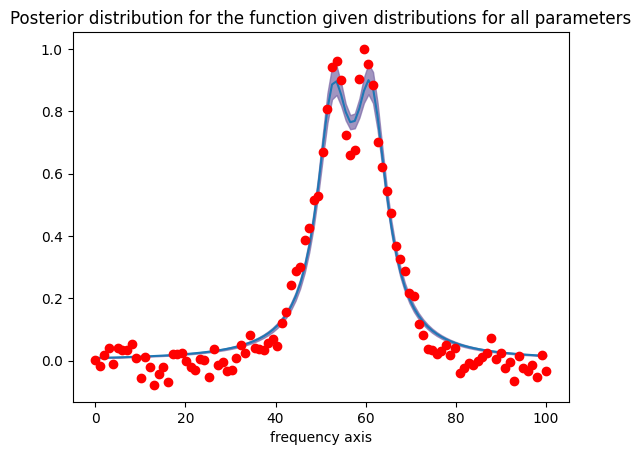

#################
1


Sample: 100%|██████████| 1200/1200 [00:22, 52.92it/s, step size=7.40e-01, acc. prob=0.931]


#################
experimental temperature: 253.15 K, inferred temperature: 252.16 K


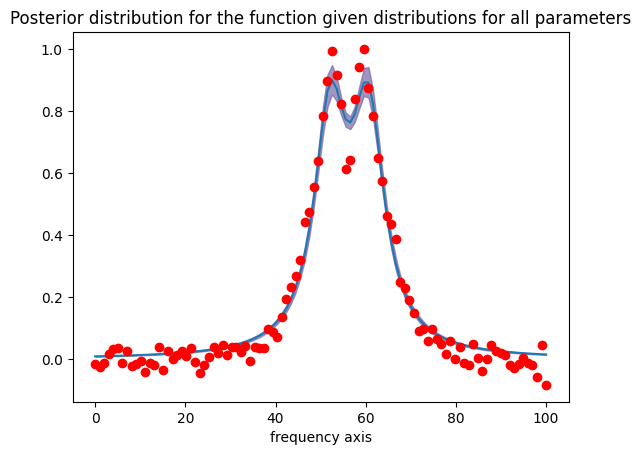

#################
2


Sample: 100%|██████████| 1200/1200 [00:15, 75.12it/s, step size=9.83e-01, acc. prob=0.847]


#################
experimental temperature: 263.15 K, inferred temperature: 259.94 K


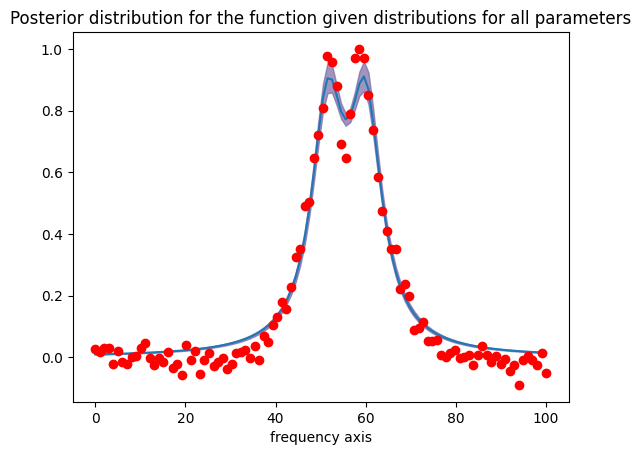

#################
3


Sample: 100%|██████████| 1200/1200 [00:19, 61.87it/s, step size=8.41e-01, acc. prob=0.903]


#################
experimental temperature: 273.15 K, inferred temperature: 267.07 K


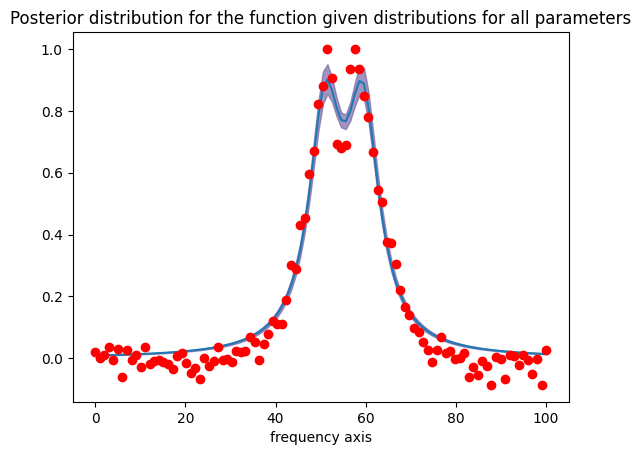

#################
4


Sample: 100%|██████████| 1200/1200 [00:20, 59.03it/s, step size=7.40e-01, acc. prob=0.926]


#################
experimental temperature: 283.15 K, inferred temperature: 278.87 K


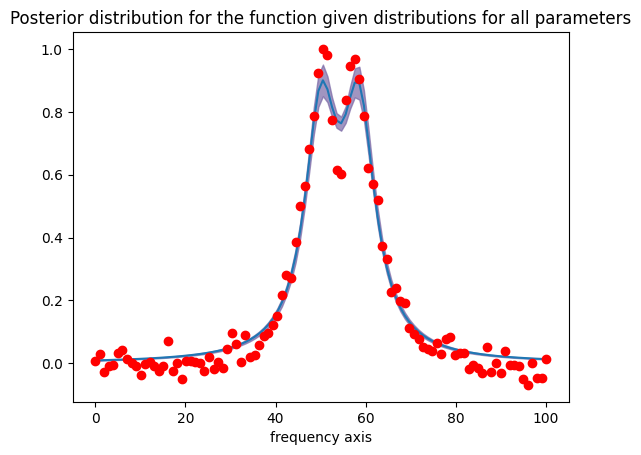

#################
5


Sample: 100%|██████████| 1200/1200 [00:21, 56.19it/s, step size=6.24e-01, acc. prob=0.930]


#################
experimental temperature: 293.15 K, inferred temperature: 289.63 K


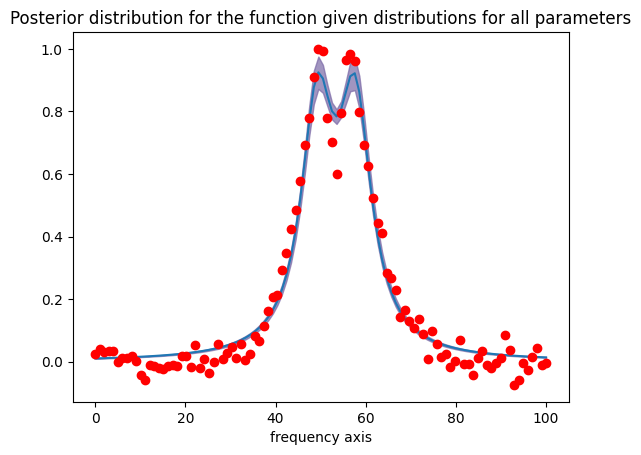

#################
6


Sample: 100%|██████████| 1200/1200 [00:19, 60.33it/s, step size=1.08e+00, acc. prob=0.907]


#################
experimental temperature: 303.15 K, inferred temperature: 299.65 K


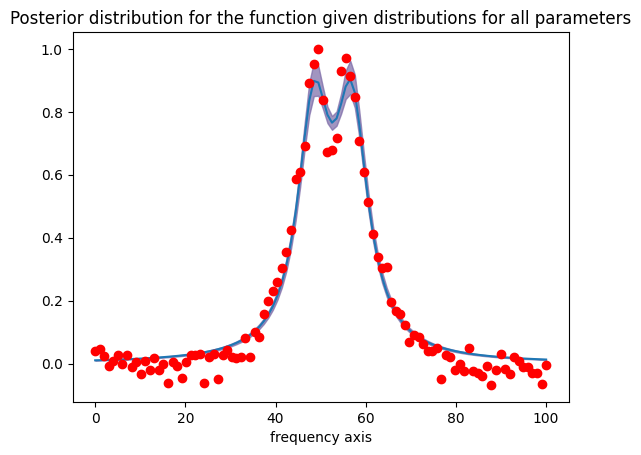

#################
7


Sample: 100%|██████████| 1200/1200 [00:20, 57.60it/s, step size=7.14e-01, acc. prob=0.920]


#################
experimental temperature: 313.15 K, inferred temperature: 307.69 K


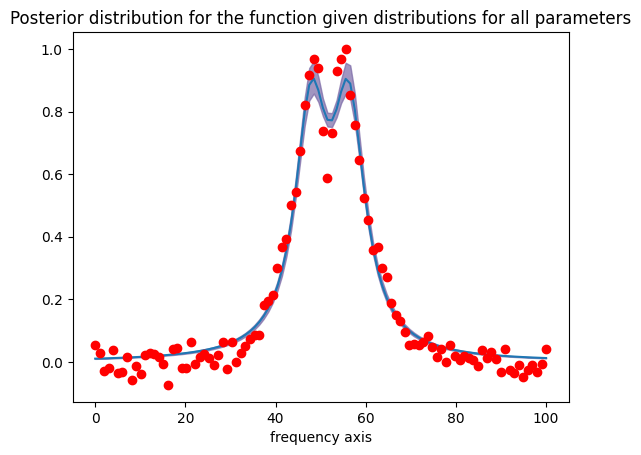

#################
8


Sample: 100%|██████████| 1200/1200 [00:21, 55.36it/s, step size=7.57e-01, acc. prob=0.929]


#################
experimental temperature: 323.15 K, inferred temperature: 319.22 K


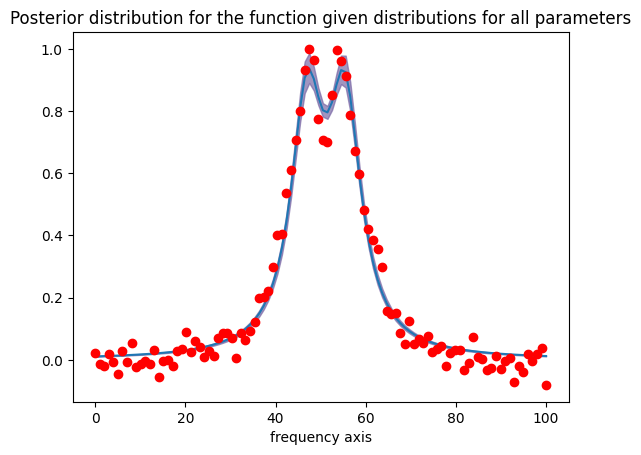

#################
9


Sample: 100%|██████████| 1200/1200 [00:21, 56.59it/s, step size=7.47e-01, acc. prob=0.922]


#################
experimental temperature: 313.15 K, inferred temperature: 307.45 K


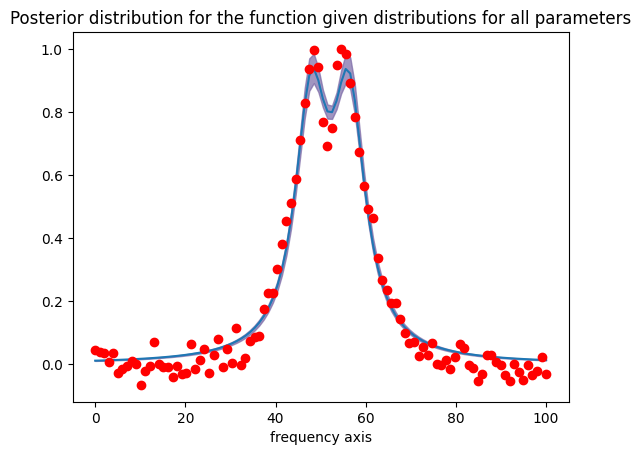

#################
10


Sample: 100%|██████████| 1200/1200 [00:19, 60.22it/s, step size=8.62e-01, acc. prob=0.911]


#################
experimental temperature: 303.15 K, inferred temperature: 296.91 K


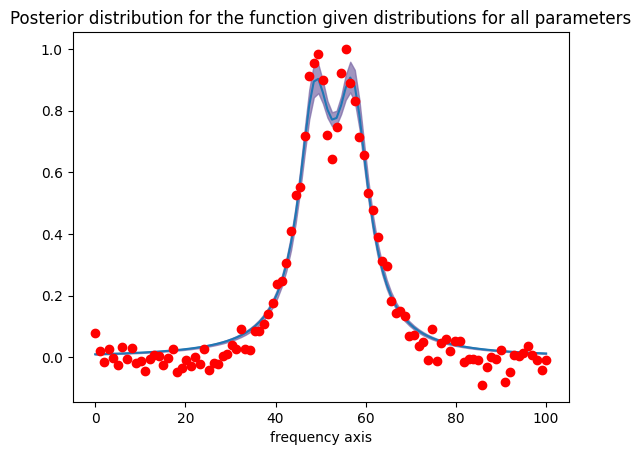

#################
11


Sample: 100%|██████████| 1200/1200 [00:19, 61.94it/s, step size=8.36e-01, acc. prob=0.894]


#################
experimental temperature: 293.15 K, inferred temperature: 288.36 K


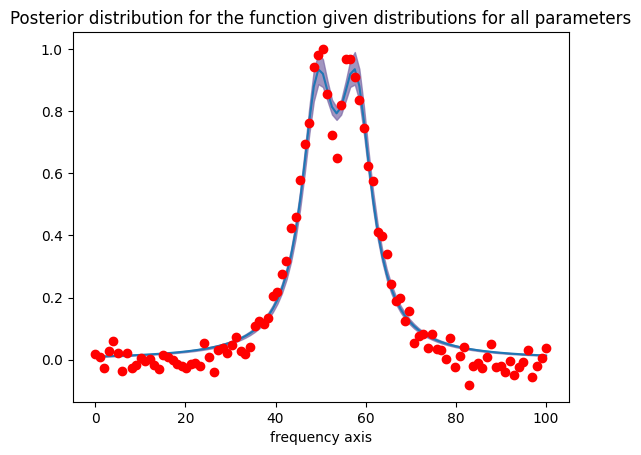

#################
12


Sample: 100%|██████████| 1200/1200 [00:22, 54.29it/s, step size=6.56e-01, acc. prob=0.930]


#################
experimental temperature: 283.15 K, inferred temperature: 277.59 K


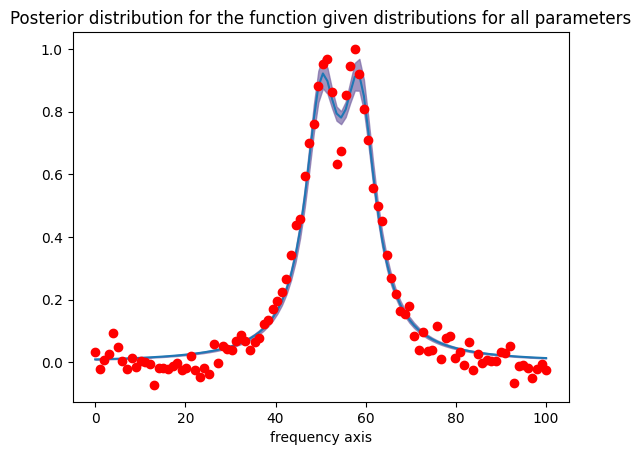

#################
13


Sample: 100%|██████████| 1200/1200 [00:23, 50.34it/s, step size=5.66e-01, acc. prob=0.936]


#################
experimental temperature: 273.15 K, inferred temperature: 268.20 K


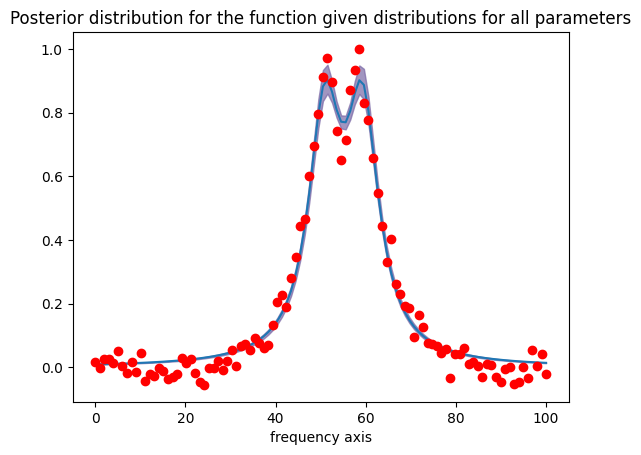

#################
14


Sample: 100%|██████████| 1200/1200 [00:21, 56.65it/s, step size=7.67e-01, acc. prob=0.924]


#################
experimental temperature: 263.15 K, inferred temperature: 260.49 K


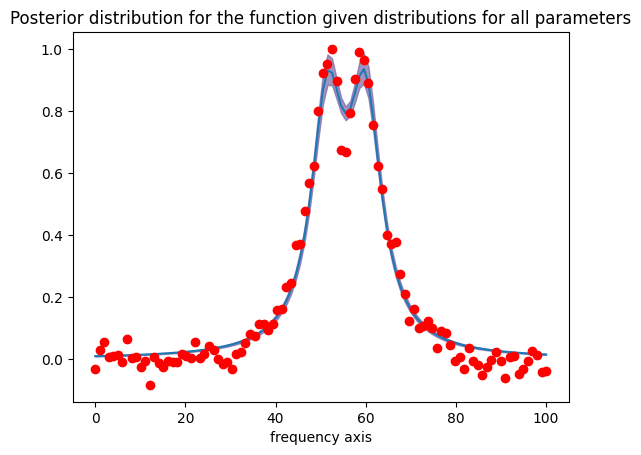

#################
15


Sample: 100%|██████████| 1200/1200 [00:25, 47.53it/s, step size=6.72e-01, acc. prob=0.933]


#################
experimental temperature: 253.15 K, inferred temperature: 251.11 K


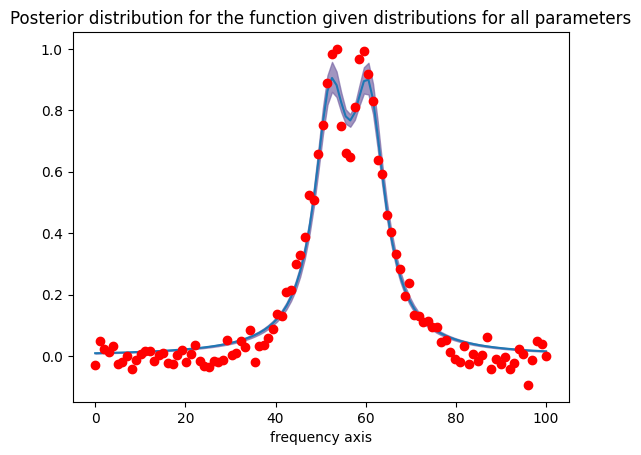

#################
16


Sample: 100%|██████████| 1200/1200 [00:24, 49.85it/s, step size=7.92e-01, acc. prob=0.902]


#################
experimental temperature: 243.15 K, inferred temperature: 245.08 K


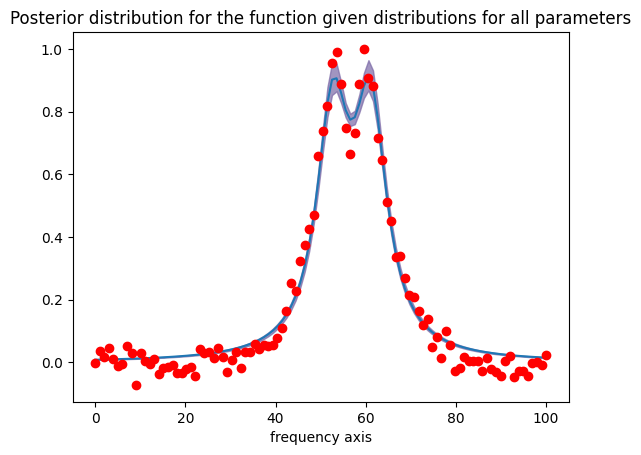

#################


In [21]:
idx = []
temp_, amp_ = [], []
amp_var = []
temp_var = []
temp_ci_high, temp_ci_low = [], []



# init vals for MCMC

init_vals = {
    "T": torch.tensor(300.),
    "gamma1": torch.tensor(7.8),
    "amp": torch.tensor(3.0),
    "var": torch.tensor(0.05),}


for j in range(0, y_esr_.shape[1]):
  print(j)
  x_obs_j, y_obs_j = dataslicer(x_scale, y_esr_, col1=j, col2=j+1)
  temps_j = temp_test_array[j]
  data_j = (x_obs_j.clone().detach().double(), y_obs_j.clone().detach().double())
  # print(y_obs_j.shape)
  kernel = NUTS(calibrated_model, jit_compile=True, init_strategy=init_to_value(values=init_vals), ignore_jit_warnings=True, max_tree_depth=6)
  posterior = MCMC(kernel, num_samples=1000, warmup_steps=200, num_chains=1)
  posterior.run(data_j)
  hmc_samples = {k: v.detach().cpu().numpy() for k, v in posterior.get_samples().items()}
  T = hmc_samples['T']
  Amp = hmc_samples['amp'] # Get posterior samples for amp
  var = hmc_samples['var'] # Get posterior samples for var
  var = hmc_samples['var'] # Get posterior samples for var
  F = F_np_calibrated(x_scale, Amp, gamma1_, T)
  qs = mquantiles(F.T, [0.025, 0.975], axis=0)
  F_mean = F.mean(axis = 1)
  idx.append(j)
  amp_.append(Amp.mean())  
  temp_.append(T.mean())
  temp_var.append(T.var())
  amp_var.append(Amp.var())
  T_ci = np.quantile(T, [0.025, 0.975])
  temp_ci_low.append(T_ci[0])
  temp_ci_high.append(T_ci[1])
  print('#################')
  print(f'experimental temperature: {temps_j.item():.2f} K, inferred temperature: {T.mean():.2f} K')
  plt.fill_between(x_scale.flatten(), qs[0], qs[1], alpha=0.7, color="#7A68A6");
  plt.plot(x_scale, F_mean)
  plt.plot(x_obs_j, y_obs_j, 'ro'); # plotting the data for this slice
  plt.xlabel('frequency axis')
  plt.title('Posterior distribution for the function given distributions for all parameters');plt.show()
  #pyro.clear_param_store()
 
  print('#################')

In [22]:
print(f'amp = {np.array(amp_).mean():.4f}')
print(f'amp error = {np.array(amp_var).mean():.6f}')

print(f'gamma1 = {np.array(gamma1_vals).mean():.4f}')
print(f'gamma1 error = {np.array(gamma1_var).mean():.6f}')

print(f'Temperature = {np.array(temp_).mean():.2f} K')
print(f'Temperature error = {np.array(temp_var).mean():.6f}')

amp = 3.2619
amp error = 0.002119
gamma1 = 8.1273
gamma1 error = 0.079926
Temperature = 277.25 K
Temperature error = 2.327925


C:\Users\zahmed\AppData\Local\Temp\1\ipykernel_18776\211130203.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  plt.plot(np.array(temp_test[:]), 'ro--')


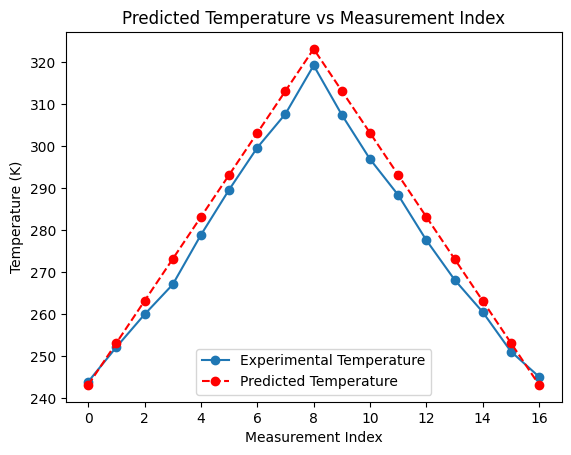

In [ ]:
temperature = np.asarray(temp_)
plt.plot(temperature, 'o-')
plt.plot(np.array(temp_test[:]), 'ro--')
plt.xlabel('Measurement Index')
plt.ylabel('Temperature (K)')
plt.legend(['Experimental Temperature', 'Predicted Temperature', ])
plt.title('Predicted Temperature vs Measurement Index')
plt.show()

C:\Users\zahmed\AppData\Local\Temp\1\ipykernel_18776\3995644142.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  plt.plot(np.array(temp_test[9:]), temperature[9:], 'k*')
C:\Users\zahmed\AppData\Local\Temp\1\ipykernel_18776\3995644142.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  sns.regplot(x = np.array(temp_test[:9]), y = temperature[:9])


<Axes: xlabel='Experimental Temperature (K)', ylabel='Inferred Temperature (K)'>

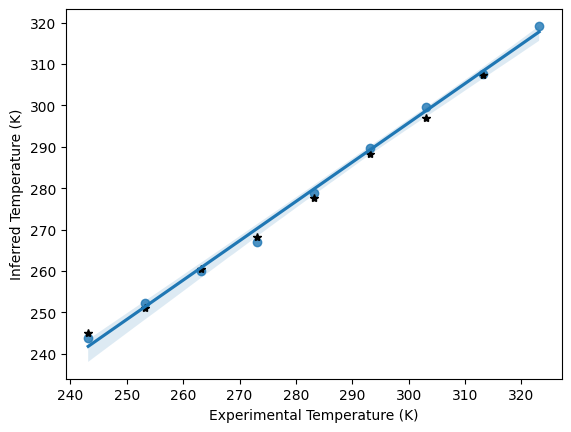

In [ ]:
plt.plot(np.asarray(temp_test[9:]), temperature[9:], 'k*')
plt.xlabel('Experimental Temperature (K)')
plt.ylabel('Inferred Temperature (K)')
import seaborn as sns
sns.regplot(x = np.asarray(temp_test[:9]), y = temperature[:9])

In [ ]:
np.sqrt(np.mean((np.asarray(temp_test) -  temperature)**2))

C:\Users\zahmed\AppData\Local\Temp\1\ipykernel_18776\3706644867.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.sqrt(np.mean((np.array(temp_test) -  temperature)**2))


np.float64(4.21396763841512)

C:\Users\zahmed\AppData\Local\Temp\1\ipykernel_18776\3809157815.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  plt.plot(np.array(temp_test) -  temperature, 'x')
C:\Users\zahmed\AppData\Local\Temp\1\ipykernel_18776\3809157815.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  plt.plot(np.array(temp_test) -  temperature, 'r')


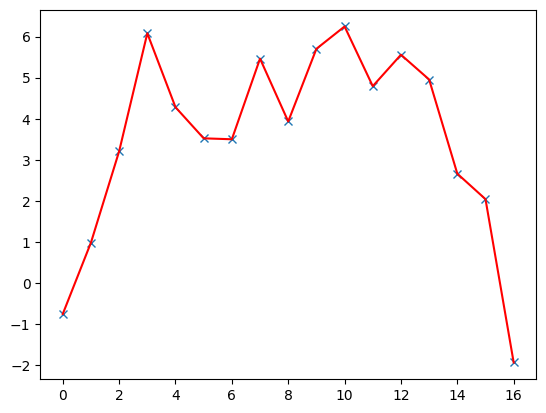

In [ ]:
plt.plot(np.asarray(temp_test) -  temperature, 'x')
plt.plot(np.asarray(temp_test) -  temperature, 'r')

C:\Users\zahmed\AppData\Local\Temp\1\ipykernel_18776\1975254165.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  plt.plot(np.array(temp_test[:9]), np.array(temp_)[:9], 'b*')
C:\Users\zahmed\AppData\Local\Temp\1\ipykernel_18776\1975254165.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  plt.plot(np.array(temp_test)[9:], np.array(temp_)[9:], 'kx')


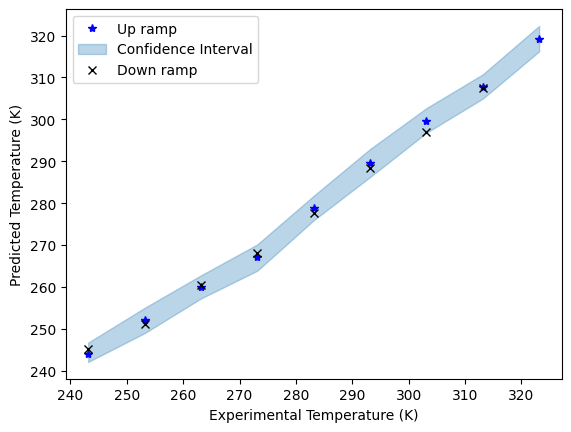

In [ ]:
# temp_, temp_var

plt.plot(np.asarray(temp_test[:9]), np.asarray(temp_)[:9], 'b*')
plt.fill_between(temp_test[:9], temp_ci_low[:9], temp_ci_high[:9] , alpha=0.3, color='C0', label='k=1')
plt.plot(np.asarray(temp_test)[9:], np.asarray(temp_)[9:], 'kx')
plt.xlabel('Experimental Temperature (K)')
plt.ylabel('Predicted Temperature (K)')
plt.legend(['Up ramp', 'Confidence Interval', 'Down ramp'])
plt.show()


np.float64(4.618002579719132)